# Reproducible Design & Analysis: Common-Source Amplifier (VN2222LL)

**EL2205 Major Assignment** **Electrical Engineering Study Program - Bandung Institute of Technology (ITB)**

**Author:** Benedictus Kenneth Setiadi (13224003)  
**Date:** April 2026

-----

## 1\. Executive Summary

This notebook presents reproducible, end-to-end documentation for the design of a Common-Source voltage amplifier using a discrete VN2222LL MOSFET. Calculations are performed using high-precision representation (64-bit floating point) to prevent the accumulation of rounding errors during design iterations. This approach ensures that the target specifications can be met with a theoretical error approaching 0%.

## 2\. Target Specifications

Based on the assignment specification document, the parameters that must be met are:

  * **Topology:** Common-Source Amplifier
  * **Voltage Gain ($A_v$):** 10 V/V (20 dB)
  * **Input Resistance ($R_{in}$):** 27 kΩ
  * **Output Resistance ($R_{out}$):** 1.5 kΩ
  * **Supply Voltage ($V_{DD}$):** 12.0 V

## 3\. Topology & Circuit Schematic

This design utilizes a Common-Source architecture with the addition of Partial Source Degeneration to stabilize the DC operating point (auto-correct) while maintaining the linearity of the AC gain against transconductance ($g_m$) fluctuations.

\<p align="center"\>
\<img src="schematic.jpg" alt="Circuit Schematic" width="600"/\>
<br>
\<i\>Figure 1: Final schematic of the VN2222LL amplifier circuit. (Replace 'schematic.jpg' with your image file name)\</i\>
\</p\>

## 4\. Design Flow & Methodology

The design is executed using a reverse-flow approach, starting from establishing the absolute output resistance, designing the DC swing headroom, extracting silicon parasitic parameters, and finally establishing the input resistance.

\<p align="center"\>
\<img src="flowchart\_path.png" alt="Design Flowchart" width="400"/\>
<br>
\<i\>Figure 2: Flowchart of the design sequence. (Replace 'flowchart\_path.png' with your image file name)\</i\>
\</p\>

## 5\. Computational Engine

The code block below sequentially executes all mathematical equations. Silicon extraction parameters ($V_{th}$, $K_n$, $\lambda$) are isolated in the top block so the computation can be instantly reproduced when the laboratory testing data is updated.

-----

## BASELINE EXACT CALCULATION AND E24 CONVERSION

In [170]:
%pip install PyLTSpice matplotlib numpy pandas scipy

Note: you may need to restart the kernel to use updated packages.


In [171]:
import numpy as np
import pandas as pd

In [172]:
import os
import numpy as np
import pandas as pd

# Matikan warning Pandas biar output notebook bersih
pd.set_option('future.no_silent_downcasting', True)

# ==============================================================================
# BLOK 1: PARAMETER KONSTAN & TARGET SPESIFIKASI (UBAH DI SINI)
# ==============================================================================
# Parameter MOSFET (Contoh: hasil rata-rata tes lab dari 10 orang)
V_TH = np.float64(1.529)         # Threshold Voltage (V)
K_N  = np.float64(15.95e-3)      # Parameter Konduksi (A/V^2) 1/2 * μ_n * C_ox * (W/L)
LAMBDA = np.float64(0.0234)      # Parameter Modulasi Panjang Kanal (V^-1)

# Spesifikasi Target & Asumsi Desain
V_DD = np.float64(12.0)          # Tegangan Supply (V)
TARGET_AV = np.float64(10.0)     # Magnitude Gain |Av| (V/V) setara 20dB
TARGET_ROUT = np.float64(1500.0) # Target Rout (Ohm)
TARGET_RIN = np.float64(27000.0) # Target Rin (Ohm)

# Asumsi awal untuk ruang swing
TARGET_VD = np.float64(7.2)      
TARGET_VS = np.float64(1.5)


# ==============================================================================
# BLOK 2: FUNGSI HELPER (SOLVER & E24 MATCHER)
# ==============================================================================
def get_closest_e24(val):
    """Mencari nilai resistor standar E24 terdekat dengan presisi tinggi."""
    e24_series = np.array([1.0, 1.1, 1.2, 1.3, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 
                           2.7, 3.0, 3.3, 3.6, 3.9, 4.3, 4.7, 5.1, 5.6, 6.2, 
                           6.8, 7.5, 8.2, 9.1, 10.0], dtype=np.float64)
    if val <= 0: return np.float64(0)

    power = np.floor(np.log10(val))
    base_val = val / (np.float64(10)**power)
    
    idx = (np.abs(e24_series - base_val)).argmin()
    res = e24_series[idx] * (np.float64(10)**power)
    
    return np.float64(res)

def solve_bias_id(v_g, r_s_tot):
    """
    Menyelesaikan persamaan kuadrat I_D akibat feedback DC dari R_S.
    Mengasumsikan pendekatan tanpa Lambda untuk estimasi hand-calc.
    """
    a = K_N * (r_s_tot**2)
    b = -(np.float64(2.0) * K_N * r_s_tot * (v_g - V_TH) + np.float64(1.0))
    c = K_N * ((v_g - V_TH)**2)
    
    id_1 = (-b + np.sqrt(b**2 - np.float64(4.0)*a*c)) / (np.float64(2.0)*a)
    id_2 = (-b - np.sqrt(b**2 - np.float64(4.0)*a*c)) / (np.float64(2.0)*a)
    
    vgs_1 = v_g - (id_1 * r_s_tot)
    return id_1 if vgs_1 > V_TH else id_2


# ==============================================================================
# BLOK 3: PERHITUNGAN JALUR 1 (MATEMATIKA EKSAK)
# ==============================================================================
# 1. Komponen & Bias Awal
RD_ex = np.float64(1600.0) 
ID_ex = (V_DD - TARGET_VD) / RD_ex
RStot_ex = TARGET_VS / ID_ex
VS_ex = ID_ex * RStot_ex
VD_ex = V_DD - (ID_ex * RD_ex)

# 2. Parameter Sinyal Kecil Eksak (FIX: Efek Lambda dimasukkan ke VGS)
VDS_ex = VD_ex - VS_ex
VGS_ex = np.sqrt(ID_ex / (K_N * (np.float64(1.0) + LAMBDA * VDS_ex))) + V_TH
gm_ex = (np.float64(2.0) * ID_ex) / (VGS_ex - V_TH)
ro_ex = np.float64(1.0) / (LAMBDA * ID_ex)

# 3. Resistor Jaringan AC & DC Eksak
numerator = (gm_ex * ro_ex * RD_ex) - (TARGET_AV * (RD_ex + ro_ex))
denominator = TARGET_AV * (1.0 + (gm_ex * ro_ex))
RS1_ex = numerator / denominator
RS2_ex = RStot_ex - RS1_ex

# 4. Resistor Input Eksak
VG_ex = VGS_ex + TARGET_VS
R1_ex = V_DD * (TARGET_RIN / VG_ex)
R2_ex = (R1_ex * TARGET_RIN) / (R1_ex - TARGET_RIN)

# 5. Output Eksak (Double Check)
Rin_ex = (R1_ex * R2_ex) / (R1_ex + R2_ex)
Rout_drain_ex = ro_ex + RS1_ex + (gm_ex * ro_ex * RS1_ex)
Rout_ex = (RD_ex * Rout_drain_ex) / (RD_ex + Rout_drain_ex)
Av_ex = (gm_ex * ro_ex * RD_ex) / (RD_ex + RS1_ex + ro_ex + (gm_ex * ro_ex * RS1_ex))


# ==============================================================================
# BLOK 4: PERHITUNGAN JALUR 2 (REALITA FISIKA - E24)
# ==============================================================================
# 1. Konversi ke standar komponen pasaran
RD_e24  = get_closest_e24(RD_ex)
RS1_e24 = get_closest_e24(RS1_ex)
RS2_e24 = get_closest_e24(RS2_ex)
R1_e24  = get_closest_e24(R1_ex)
R2_e24  = get_closest_e24(R2_ex)

# 2. Pergeseran Bias DC akibat E24
VG_e24 = V_DD * (R2_e24 / (R1_e24 + R2_e24))
RStot_e24 = RS1_e24 + RS2_e24
ID_e24 = solve_bias_id(VG_e24, RStot_e24)

VS_e24 = ID_e24 * RStot_e24
VD_e24 = V_DD - (ID_e24 * RD_e24)
VGS_e24 = VG_e24 - VS_e24

# 3. Pergeseran Parameter Sinyal Kecil akibat ID baru
gm_e24 = (np.float64(2.0) * ID_e24) / (VGS_e24 - V_TH)
ro_e24 = np.float64(1.0) / (LAMBDA * ID_e24)

# 4. Finalisasi Output AC dengan model E24
Rin_e24 = (R1_e24 * R2_e24) / (R1_e24 + R2_e24)
Rout_drain_e24 = ro_e24 + RS1_e24 + (gm_e24 * ro_e24 * RS1_e24)
Rout_e24 = (RD_e24 * Rout_drain_e24) / (RD_e24 + Rout_drain_e24)
Av_e24 = (gm_e24 * ro_e24 * RD_e24) / (RD_e24 + RS1_e24 + ro_e24 + (gm_e24 * ro_e24 * RS1_e24))


# ==============================================================================
# BLOK 5: UJI KETAHANAN AUTO-CORRECT (MENGGUNAKAN BIAS E24)
# ==============================================================================
ID_50mV  = solve_bias_id(VG_e24 + np.float64(0.05), RStot_e24)
ID_200mV = solve_bias_id(VG_e24 + np.float64(0.20), RStot_e24)
ID_500mV = solve_bias_id(VG_e24 + np.float64(0.50), RStot_e24)


# ==============================================================================
# BLOK 6: KALKULASI GALAT, RENDER TABEL & EXPORT CSV
# ==============================================================================
def calc_err(target, actual):
    return np.abs(target - actual) / target * 100

data = [
    # KOMPONEN RESISTOR
    ("Komponen", "R_D (Ohm)", "-", RD_ex, RD_e24, "-", "-"),
    ("Komponen", "R_S1 (Ohm)", "-", RS1_ex, RS1_e24, "-", "-"),
    ("Komponen", "R_S2 (Ohm)", "-", RS2_ex, RS2_e24, "-", "-"),
    ("Komponen", "R_1 (Ohm)", "-", R1_ex, R1_e24, "-", "-"),
    ("Komponen", "R_2 (Ohm)", "-", R2_ex, R2_e24, "-", "-"),
    
    # BIAS DC
    ("Bias DC", "V_G (V)", "-", VG_ex, VG_e24, "-", "-"),
    ("Bias DC", "V_S (V)", TARGET_VS, VS_ex, VS_e24, "-", "-"),
    ("Bias DC", "V_D (V)", TARGET_VD, VD_ex, VD_e24, "-", "-"),
    ("Bias DC", "V_GS (V)", "-", VGS_ex, VGS_e24, "-", "-"),
    ("Bias DC", "I_D (mA)", "-", ID_ex * 1000, ID_e24 * 1000, "-", "-"),
    
    # PARAMETER SMALL SIGNAL
    ("Sinyal Kecil", "g_m (A/V)", "-", gm_ex, gm_e24, "-", "-"),
    ("Sinyal Kecil", "r_o (Ohm)", "-", ro_ex, ro_e24, "-", "-"),
    
    # PERFORMA AC
    ("Performa AC", "R_in (Ohm)", TARGET_RIN, Rin_ex, Rin_e24, calc_err(TARGET_RIN, Rin_ex), calc_err(TARGET_RIN, Rin_e24)),
    ("Performa AC", "R_out (Ohm)", TARGET_ROUT, Rout_ex, Rout_e24, calc_err(TARGET_ROUT, Rout_ex), calc_err(TARGET_ROUT, Rout_e24)),
    ("Performa AC", "Gain |A_v| (V/V)", TARGET_AV, Av_ex, Av_e24, calc_err(TARGET_AV, Av_ex), calc_err(TARGET_AV, Av_e24)),
    
    # TEST AUTO-CORRECTION DC
    ("Uji Stabilitas", "I_D (+50mV dVg)", "-", "-", ID_50mV * 1000, "-", "-"),
    ("Uji Stabilitas", "I_D (+200mV dVg)", "-", "-", ID_200mV * 1000, "-", "-"),
    ("Uji Stabilitas", "I_D (+500mV dVg)", "-", "-", ID_500mV * 1000, "-", "-")
]

df = pd.DataFrame(data, columns=["Kategori", "Parameter", "Target", "Hasil Eksak", "Hasil E24", "Galat Eksak (%)", "Galat E24 (%)"])

# Formatting output
pd.options.display.float_format = '{:.6f}'.format
df_print = df.replace("-", np.nan).fillna("-")

# ---------------------------------------------------------
# BIKIN FOLDER & EXPORT CSV
# ---------------------------------------------------------
output_dir = "./export_data/baseline"
os.makedirs(output_dir, exist_ok=True) # Bikin folder kalau belum ada
csv_filename = f"{output_dir}/Summary_Exact Mathematical Calculations_CS_Amp_Baseline.csv"

# Export dataframe aslinya (biar data '-' tetap bersih atau bisa dibaca Excel)
df.to_csv(csv_filename, index=False)

print(f"📁 FOLDER DAN FILE BERHASIL DIBUAT!")
print(f"✅ Data diekspor ke : {csv_filename}\n")

print("="*105)
print(f"{'RINGKASAN PERHITUNGAN REPRODUCIBLE (EKSAK VS E24)':^105}")
print("="*105)
print(df_print.to_string(index=False))

📁 FOLDER DAN FILE BERHASIL DIBUAT!
✅ Data diekspor ke : ./export_data/baseline/Summary_Exact Mathematical Calculations_CS_Amp_Baseline.csv

                            RINGKASAN PERHITUNGAN REPRODUCIBLE (EKSAK VS E24)                            
      Kategori        Parameter       Target  Hasil Eksak    Hasil E24 Galat Eksak (%) Galat E24 (%)
      Komponen        R_D (Ohm)            -  1600.000000  1600.000000               -             -
      Komponen       R_S1 (Ohm)            -    84.077694    82.000000               -             -
      Komponen       R_S2 (Ohm)            -   415.922306   430.000000               -             -
      Komponen        R_1 (Ohm)            - 94285.450421 91000.000000               -             -
      Komponen        R_2 (Ohm)            - 37834.437392 39000.000000               -             -
       Bias DC          V_G (V)            -     3.436373     3.600000               -             -
       Bias DC          V_S (V)     1.500000   

## SPICE SIMULATION BASELINE (NO LOAD AND PARASITICS)

In [173]:
!open -a LTspice "./sim_assets/baseline/CS_Amp_Baseline.asc"


# 🔬 Common-Source Amplifier: 5-Phase Verification Plan

This notebook automates the verification of a Common-Source Amplifier design using Python and headless LTspice simulations. To ensure robust performance and trace potential discrepancies, the testing pipeline is divided into 5 isolated phases (Termins):

### 🔹 Phase 1: DC Bias & Small-Signal Extraction (`.op`)
**Objective:** Establish the baseline operating point (Q-point) using standard E24 resistor values. This phase extracts exact theoretical small-signal parameters ($g_m$, $r_o$) directly from the SPICE Level 1 physics model to calculate the expected Gain, $R_{in}$, and $R_{out}$.

### 🔹 Phase 2: Time-Domain Transient Analysis (`.tran`)
**Objective:** Verify the amplifier's real-time signal processing. This phase acts as a virtual oscilloscope to validate the 180° phase inversion, measure practical voltage gain ($V_{out(p-p)} / V_{in(p-p)}$), and ensure the output voltage swing operates safely without clipping.

### 🔹 Phase 3: Frequency Response & Bode Plot (`.ac`)
**Objective:** Analyze the amplifier's behavior across a wide frequency spectrum. This sweeps the AC input to plot the frequency response, determining the maximum Midband Gain and identifying the cutoff frequencies (Bandwidth).

### 🔹 Phase 4: AC Impedance Verification
**Objective:** Empirically validate the input resistance ($R_{in}$) and output resistance ($R_{out}$). By utilizing AC test sources and Thevenin's theorem within the simulation, this phase cross-references the actual simulated impedance against Phase 1's mathematical models.

### 🔹 Phase 5: MOSFET Device Characteristics (`.dc`)
**Objective:** Visualize the intrinsic physical boundaries of the MOSFET. By generating the $I_D-V_{DS}$ (Output) and $I_D-V_{GS}$ (Transfer) curves and mapping the actual Q-point onto them, this phase visually proves that the device is strictly operating within the saturation region.

# 🔬 Termin 1: DC Bias & Parameter Ekstraksi (Small-Signal)
**Tujuan:** Menginisialisasi titik kerja (Q-Point) dari penguat *Common-Source* dengan beban resistor E24. Pada termin ini, skematik LTspice akan diinjeksi dengan parameter desain yang telah dihitung, dieksekusi secara *headless* (di latar belakang), dan parameter *small-signal* ($g_m$, $r_o$) akan diekstrak menggunakan persamaan model fisik eksak (Model SPICE Level 1).

**Pentingnya Tahap Ini:**
Tanpa pondasi DC yang stabil (berada di tengah daerah saturasi), ayunan sinyal AC (Termin 2) akan mengalami *clipping*.

In [174]:
import os
import numpy as np
import pandas as pd
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("⚙️ [Phase 1] Executing DC Operating Point Analysis (.op)...")

# ===================================================================
# 1. PARAMETER INJECTION
# ===================================================================
my_params = {
    'my_VTO': V_TH,               
    'my_KP': K_N * 2,             
    'my_LAMBDA': LAMBDA,
    'RD_val': RD_e24,
    'RS1_val': RS1_e24,
    'RS2_val': RS2_e24,
    'R1_val': R1_e24,
    'R2_val': R2_e24,
    'Cin_val': "10u",
    'Cout_val': "10u",
    'Cs_val': "100u"
}

# ===================================================================
# 2. HEADLESS LTSPICE EXECUTION
# ===================================================================
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"
runner = SimRunner(output_folder='./sim_results/baseline/termin1', simulator=mac_path)

# Update netlist & run silently
netlist = SpiceEditor("./sim_assets/baseline/CS_Amp_Baseline_Termin1_copy.net") 
netlist.set_parameters(**my_params)
runner.run_now(netlist)

# ===================================================================
# 3. EXTRACTION, CALCULATION, & EXPORT
# ===================================================================
try:
    op_file = "sim_results/baseline/termin1/CS_Amp_Baseline_Termin1_copy_1.op.raw" 
    op_raw = RawRead(op_file)
    
    # Set Pandas to show maximum float precision natively
    pd.set_option('display.precision', 15)
    
    # --- A. FULL LTSPICE .OP DUMP (SCALED) ---
    all_op_data = []
    nodes = {}
    
    # Extract & scale automatically
    for var in op_raw.get_trace_names():
        val = np.real(op_raw.get_trace(var).get_wave()[0])
        nodes[var.lower()] = val
        
        # Kalau dia arus (diawali huruf 'i' atau 'I'), jadikan miliAmpere
        if var.lower().startswith('i'):
            all_op_data.append([var, val * 1000, "mA"])
        # Sisanya diasumsikan Tegangan (V)
        else:
            all_op_data.append([var, val, "V"])
            
    print("\n✅ === FULL LTSPICE DC OPERATING POINT (RAW DUMP) === ✅")
    df_all_op = pd.DataFrame(all_op_data, columns=['LTspice Variable', 'Value (Full Precision)', 'Unit'])
    display(HTML(df_all_op.to_html(index=False)))

    # ---------------------------------------------------------
    # EXPORT CSV RAW DUMP
    # ---------------------------------------------------------
    output_dir = "./export_data/baseline"
    os.makedirs(output_dir, exist_ok=True)
    csv_raw_filename = f"{output_dir}/Termin1_operating_point_baseline.csv"
    df_all_op.to_csv(csv_raw_filename, index=False)
    print(f"📁 RAW DATA EXPORTED TO: {csv_raw_filename}")

    # --- B. SUMMARY Q-POINT & SMALL-SIGNAL ---
    print("\n🔍 === EXACT PARAMETER SUMMARY (SPICE-BASED) === 🔍")
    
    # Extract Q-Point variables
    ID = nodes.get('id(m1)', 0.0)
    VGS = nodes.get('v(gate)', 0.0) - nodes.get('v(source)', 0.0)
    VDS = nodes.get('v(drain)', 0.0) - nodes.get('v(source)', 0.0)
    VOV = VGS - V_TH
    
    # Small-Signal parameters
    gm = (2 * ID) / VOV
    ro = 1 / (LAMBDA * ID) if LAMBDA > 0 else float('inf')
    Rin = (R1_e24 * R2_e24) / (R1_e24 + R2_e24)
    RD = RD_e24
    RS1 = RS1_e24

    # Gain & Rout Exact Formula
    numerator = - (gm * RD * ro)
    denominator = ro + RD + RS1 * (1 + gm * ro)
    Av_exact = numerator / denominator
    r_looking_into_drain = ro + RS1 + (gm * ro * RS1)
    Rout_exact = (RD * r_looking_into_drain) / (RD + r_looking_into_drain)

    # Gabungan Q-Point dan Parameter AC
    ss_results = [
        ["Operation Region", "Saturation 🟢" if VDS > VOV else "Triode / Cut-off 🔴", "-"],
        ["Drain Current (ID)", ID * 1000, "mA"],
        ["Gate-Source Voltage (VGS)", VGS, "V"],
        ["Drain-Source Voltage (VDS)", VDS, "V"],
        ["Overdrive Voltage (VOV)", VOV, "V"],
        ["Transconductance (gm)", gm * 1000, "mA/V"],
        ["Output Resistance (ro)", ro, "Ohm"],
        ["Input Resistance (Rin)", Rin, "Ohm"],
        ["Output Resistance (Rout)", Rout_exact, "Ohm"],
        ["Theoretical Gain (Av)", Av_exact, "V/V"]
    ]
    
    df_ss = pd.DataFrame(ss_results, columns=['Parameter', 'Calculated Value (Raw Float)', 'Unit'])
    display(HTML(df_ss.to_html(index=False)))

    # Export Summary CSV juga sekalian biar mantap
    csv_ss_filename = f"{output_dir}/Termin1_small_signal_baseline.csv"
    df_ss.to_csv(csv_ss_filename, index=False)
    print(f"📁 SUMMARY EXPORTED TO: {csv_ss_filename}\n")

    # Reset precision option
    pd.reset_option('display.precision')

except Exception as e:
    print(f"❌ Error during Phase 1: {e}")

⚙️ [Phase 1] Executing DC Operating Point Analysis (.op)...

✅ === FULL LTSPICE DC OPERATING POINT (RAW DUMP) === ✅


LTspice Variable,Value (Full Precision),Unit
V(drain),6.853135,V
V(gate),3.600000,V
V(source),1.646997,V
V(s_mid),1.383220,V
V(vdd),12.000000,V
V(vin),0.000000,V
V(vout),0.000069,V
Id(M1),3.216796,mA
Ig(M1),0.000000,mA
Ib(M1),-0.000000,mA


📁 RAW DATA EXPORTED TO: ./export_data/baseline/Termin1_operating_point_baseline.csv

🔍 === EXACT PARAMETER SUMMARY (SPICE-BASED) === 🔍


Parameter,Calculated Value (Raw Float),Unit
Operation Region,Saturation 🟢,-
Drain Current (ID),3.216796,mA
Gate-Source Voltage (VGS),1.953003,V
Drain-Source Voltage (VDS),5.206138,V
Overdrive Voltage (VOV),0.424003,V
Transconductance (gm),15.173456,mA/V
Output Resistance (ro),13284.971955,Ohm
Input Resistance (Rin),27300.000000,Ohm
Output Resistance (Rout),1518.720986,Ohm
Theoretical Gain (Av),-10.240086,V/V


📁 SUMMARY EXPORTED TO: ./export_data/baseline/Termin1_small_signal_baseline.csv



# 🌊 Phase 2: Time-Domain Transient Analysis (.tran)
**Objective:** To verify the amplifier's real-time signal processing capabilities using a Virtual Oscilloscope. This phase injects a 1 kHz, 20 mV amplitude sinusoidal signal into the Gate to empirically measure the practical Voltage Gain ($V_{out(p-p)} / V_{in(p-p)}$). 

**Key Verifications:**
1. **Voltage Amplification:** Ensuring the output swing matches the theoretical Gain calculated in Phase 1.
2. **Phase Inversion:** Visually demonstrating the 180° phase shift inherent to Common-Source topology.
3. **Headroom Integrity:** Confirming that the signal oscillates cleanly around the DC Q-Point without hitting the triode or cut-off regions (No Clipping).

*Note: The first 2ms of the simulation are filtered out to avoid start-up transient effects from the coupling capacitors.*

🌊 [Phase 2] Executing Time-Domain Transient Analysis (.tran)...

✅ === TRANSIENT MEASUREMENT (STEADY-STATE) === ✅


Parameter,Measurement
Input Swing (Gate p-p),39.962 mV
Output Swing (Drain p-p),411.621 mV
Practical Gain |Av|,10.300 V/V


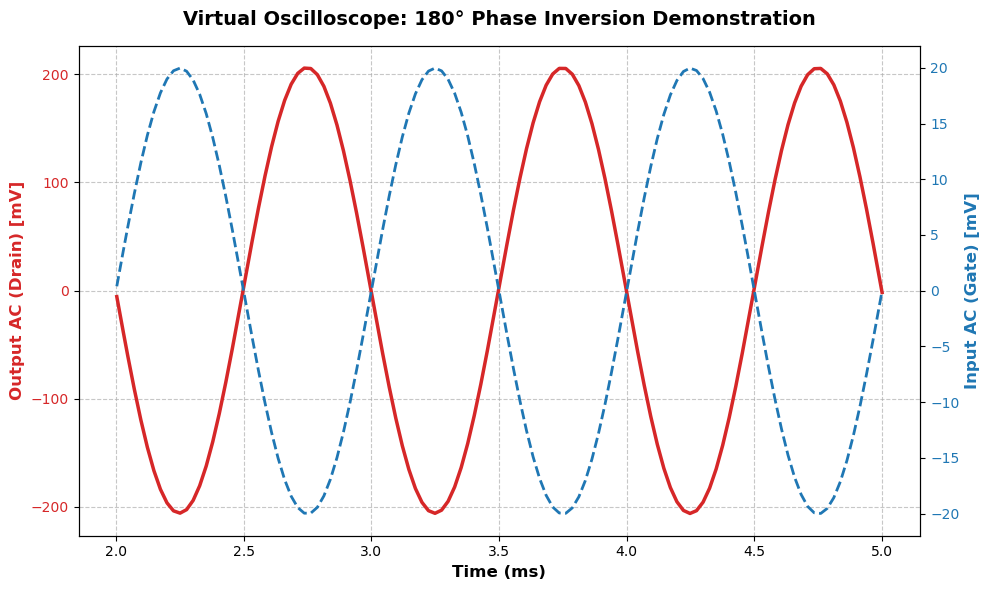


📁 FILES EXPORTED:
- Plot Image : ./export_data/baseline/Termin2_oscilloscope_plot_baseline.png
- Scope Data : ./export_data/baseline/Termin2_transient_waveforms_baseline.csv



In [175]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("🌊 [Phase 2] Executing Time-Domain Transient Analysis (.tran)...")

# ===================================================================
# 1. SETUP ENGINE & TARGET NETLIST
# ===================================================================
target_netlist = "./sim_assets/baseline/CS_Amp_Baseline_Termin2_copy.net" 
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"
runner = SimRunner(output_folder='./sim_results/baseline/termin2', simulator=mac_path)

# ===================================================================
# 2. INJECT PARAMETERS & RUN SILENTLY
# ===================================================================
editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 3. ROBUST DATA EXTRACTION 
    # ===================================================================
    tran_file = "sim_results/baseline/termin2/CS_Amp_Baseline_Termin2_copy_1.raw"
    tran_raw = RawRead(tran_file)
    
    # HACK ANTI-ERROR: Coba get_axis(), kalau gagal, tarik trace 'time'
    try:
        time = tran_raw.get_axis()
        if time is None:
            time = tran_raw.get_trace("time").get_wave()
    except:
        time = tran_raw.get_trace("time").get_wave()

    # Pastikan semuanya dipaksa jadi bilangan Real (membuang sisa array complex)
    time = np.real(time)
    
    # Sesuaikan dengan nama node di .net lu (v(gate) dan v(drain) atau v(vin) dan v(vout))
    try:
        v_gate = np.real(tran_raw.get_trace("v(gate)").get_wave())
        v_drain = np.real(tran_raw.get_trace("v(drain)").get_wave())
    except:
        print("⚠️ Node v(gate) atau v(drain) ga ketemu! Coba cek nama node di file .net lu (bisa jadi v(vin) atau v(vout))")
        # Berhenti eksekusi kalau node ga ketemu
        raise 
    
    # Filter data: Ambil waktu > 2ms untuk steady-state
    valid_idx = np.where(time > 0.002)[0]
    
    # Cegah error kalau ternyata simulasi jalan tapi datanya kosong
    if len(valid_idx) == 0:
        raise ValueError("Simulasi jalan, tapi data setelah 2ms kosong. Cek durasi .tran lu!")

    time_valid = time[valid_idx]
    vg_valid = v_gate[valid_idx]
    vd_valid = v_drain[valid_idx]
    
    # Hitung Swing (Peak-to-Peak)
    vg_pp = np.max(vg_valid) - np.min(vg_valid)
    vd_pp = np.max(vd_valid) - np.min(vd_valid)
    practical_gain = vd_pp / vg_pp
    
    print("\n✅ === TRANSIENT MEASUREMENT (STEADY-STATE) === ✅")
    res_data = [
        ["Input Swing (Gate p-p)", f"{vg_pp*1000:.3f} mV"],
        ["Output Swing (Drain p-p)", f"{vd_pp*1000:.3f} mV"],
        ["Practical Gain |Av|", f"{practical_gain:.3f} V/V"]
    ]
    display(HTML(pd.DataFrame(res_data, columns=['Parameter', 'Measurement']).to_html(index=False)))

    # ===================================================================
    # 4. PLOTTING: THE VIRTUAL OSCILLOSCOPE
    # ===================================================================
    vg_ac = vg_valid - np.mean(vg_valid)
    vd_ac = vd_valid - np.mean(vd_valid)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    color1 = '#d62728' 
    ax1.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Output AC (Drain) [mV]', color=color1, fontsize=12, fontweight='bold')
    ax1.plot(time_valid * 1000, vd_ac * 1000, color=color1, linewidth=2.5, label='Output (V_drain)')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2 = ax1.twinx()  
    color2 = '#1f77b4' 
    ax2.set_ylabel('Input AC (Gate) [mV]', color=color2, fontsize=12, fontweight='bold')
    ax2.plot(time_valid * 1000, vg_ac * 1000, color=color2, linewidth=2, linestyle='--', label='Input (V_gate)')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title("Virtual Oscilloscope: 180° Phase Inversion Demonstration", fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    
    # ---------------------------------------------------------
    # 5. EXPORT DATA & IMAGE
    # ---------------------------------------------------------
    output_dir = "./export_data/baseline"
    os.makedirs(output_dir, exist_ok=True)
    
    img_filename = f"{output_dir}/Termin2_oscilloscope_plot_baseline.png"
    plt.savefig(img_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    df_tran = pd.DataFrame({
        'Time_ms': time_valid * 1000,
        'V_Gate_V': vg_valid,
        'V_Drain_V': vd_valid
    })
    
    step_size = max(1, len(df_tran) // 500)
    csv_tran_filename = f"{output_dir}/Termin2_transient_waveforms_baseline.csv"
    df_tran.iloc[::step_size].to_csv(csv_tran_filename, index=False)
    
    print(f"\n📁 FILES EXPORTED:")
    print(f"- Plot Image : {img_filename}")
    print(f"- Scope Data : {csv_tran_filename}\n")

except Exception as e:
    print(f"❌ Error during Phase 2 Extraction: {e}")

# 📈 Phase 3: AC Frequency Response & Bode Plot (.ac)
**Objective:** To analyze the amplifier's behavior across a wide frequency spectrum (1 Hz to 100 MHz). This phase utilizes a small-signal AC sweep to generate a Bode Plot, extracting critical frequency-domain parameters.

**Key Verifications:**
1. **Midband Gain ($A_{v(mid)}$):** Validating the peak AC gain against the theoretical DC extraction from Phase 1.
2. **Bandwidth Extraction:** Automatically locating the lower ($f_L$) and upper ($f_H$) -3dB cutoff frequencies.
3. **Phase Response:** Analyzing the phase shift behavior, confirming the 180° inversion in the midband region.

📈 [Phase 3] Executing AC Frequency Response (.ac) - Full Analysis...

📝 === COMPREHENSIVE FREQUENCY ANALYSIS === 📝


Metric,Value,Unit
Midband Gain (Linear),10.299816,V/V
Midband Gain (Decibel),20.256589,dB
Midband Phase Shift,-179.999994,deg
Lower Cutoff Freq (f_L),13.18 Hz,Hz
Upper Cutoff Freq (f_H),97.72 MHz,Hz
Bandwidth (-3dB),97.72 MHz,Hz
Unity Gain Freq (f_T),-,Hz
Input Resistance (Rin @ Mid),27300.000000,Ohm
Output Resistance (Rout @ Mid),1518.720986,Ohm


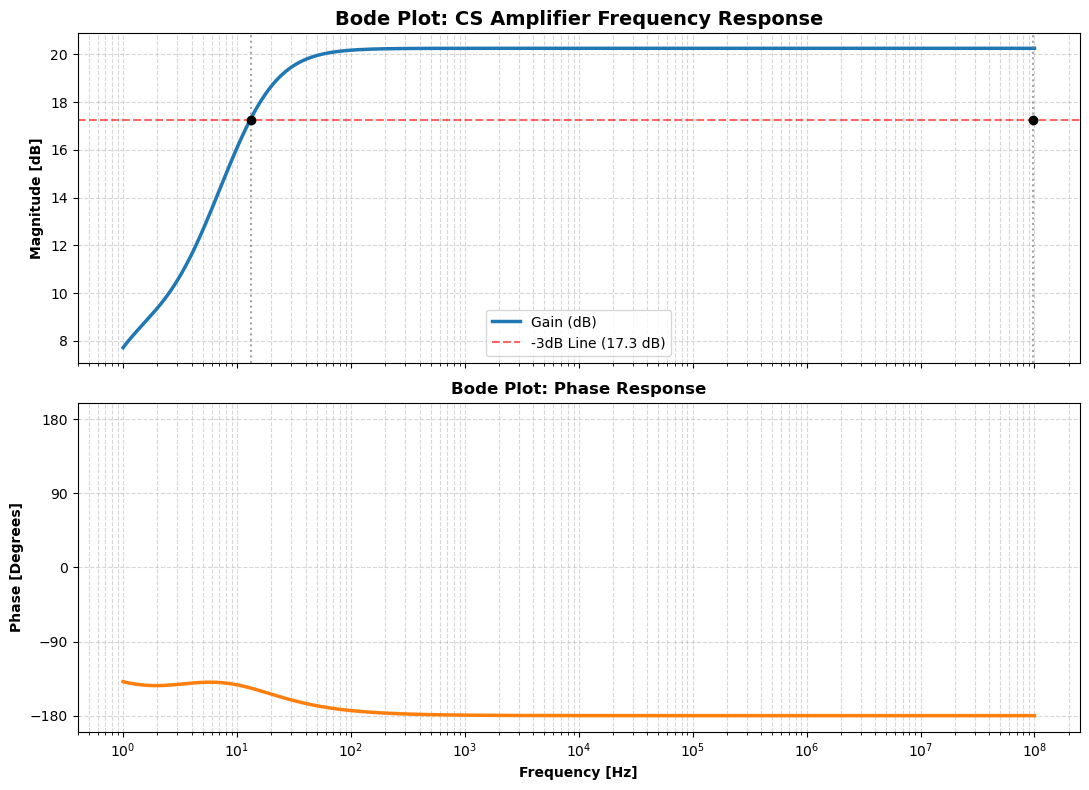


📁 FILES EXPORTED:
- Plot Image : ./export_data/baseline/Termin3_bode_plot_baseline.png
- AC Data    : ./export_data/baseline/Termin3_bode_data_baseline.csv
- Metrics    : ./export_data/baseline/Termin3_metrics_baseline.csv



In [176]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("📈 [Phase 3] Executing AC Frequency Response (.ac) - Full Analysis...")

# ===================================================================
# 0. DIRECTORY MANAGEMENT (Custom Workspace)
# ===================================================================
asset_dir = "./sim_assets/baseline"
result_dir = "./sim_results/baseline/termin3"
export_dir = "./export_data/baseline"

# Pastikan folder output exist biar Python ga ngambek
os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

# Target netlist
target_netlist = f"{asset_dir}/CS_Amp_Baseline_Termin3_copy.net"

# ===================================================================
# 1. SETUP ENGINE & RUN SILENTLY
# ===================================================================
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"

# SimRunner akan nge-dump hasil ke result_dir
runner = SimRunner(output_folder=result_dir, simulator=mac_path)

editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 2. ROBUST DATA EXTRACTION 
    # ===================================================================
    # SimRunner otomatis nambahin '_1' di akhir nama file asli
    ac_file = f"{result_dir}/CS_Amp_Baseline_Termin3_copy_1.raw"
    ac_raw = RawRead(ac_file)
    
    # Ekstraksi sumbu X (Frekuensi)
    try:
        freq = ac_raw.get_axis()
        if freq is None: freq = ac_raw.get_trace("frequency").get_wave()
    except:
        freq = ac_raw.get_trace("frequency").get_wave()
        
    freq = np.real(freq) 
    
    # Ekstraksi Output (Kompleks)
    v_drain_complex = ac_raw.get_trace("v(drain)").get_wave()
    
    magnitude_lin = np.abs(v_drain_complex)
    magnitude_db = 20 * np.log10(magnitude_lin)
    phase_deg = np.angle(v_drain_complex, deg=True)
    
    # ===================================================================
    # 3. ADVANCED METRICS CALCULATION
    # ===================================================================
    max_idx = np.argmax(magnitude_db)
    mid_gain_db = magnitude_db[max_idx]
    mid_gain_lin = magnitude_lin[max_idx]
    mid_phase = phase_deg[max_idx]
    
    cutoff_target_db = mid_gain_db - 3.0
    
    low_band_freq = freq[:max_idx]
    low_band_db = magnitude_db[:max_idx]
    
    high_band_freq = freq[max_idx:]
    high_band_db = magnitude_db[max_idx:]
    
    # Cari f_L dan f_H
    f_L = low_band_freq[np.argmin(np.abs(low_band_db - cutoff_target_db))] if len(low_band_freq) > 0 else freq[0]
    f_H = high_band_freq[np.argmin(np.abs(high_band_db - cutoff_target_db))] if len(high_band_freq) > 0 else freq[-1]
    bandwidth = f_H - f_L

    # Unity Gain Frequency (0 dB)
    if np.min(high_band_db) <= 0:
        f_unity = high_band_freq[np.argmin(np.abs(high_band_db - 0))]
    else:
        f_unity = None

    # Theoretical Impedance at Midband (Menggunakan variabel dari memory Phase 1)
    rin_mid = (R1_e24 * R2_e24) / (R1_e24 + R2_e24)
    r_drain_internal = ro + RS1_e24 + (gm * ro * RS1_e24)
    rout_mid = (RD_e24 * r_drain_internal) / (RD_e24 + r_drain_internal)

    # ===================================================================
    # 4. COMPREHENSIVE ANALYSIS TABLE
    # ===================================================================
    def fmt_f(f):
        if f is None: return "-"
        if f >= 1e6: return f"{f/1e6:.2f} MHz"
        elif f >= 1e3: return f"{f/1e3:.2f} kHz"
        else: return f"{f:.2f} Hz"

    print("\n📝 === COMPREHENSIVE FREQUENCY ANALYSIS === 📝")
    analysis_data = [
        ["Midband Gain (Linear)", f"{mid_gain_lin:.6f}", "V/V"],
        ["Midband Gain (Decibel)", f"{mid_gain_db:.6f}", "dB"],
        ["Midband Phase Shift", f"{mid_phase:.6f}", "deg"],
        ["Lower Cutoff Freq (f_L)", fmt_f(f_L), "Hz"],
        ["Upper Cutoff Freq (f_H)", fmt_f(f_H), "Hz"],
        ["Bandwidth (-3dB)", fmt_f(bandwidth), "Hz"],
        ["Unity Gain Freq (f_T)", fmt_f(f_unity), "Hz"],
        ["Input Resistance (Rin @ Mid)", f"{rin_mid:.6f}", "Ohm"],
        ["Output Resistance (Rout @ Mid)", f"{rout_mid:.6f}", "Ohm"]
    ]
    
    df_analysis = pd.DataFrame(analysis_data, columns=['Metric', 'Value', 'Unit'])
    display(HTML(df_analysis.to_html(index=False)))

    # ===================================================================
    # 5. PLOTTING: THE BODE PLOT
    # ===================================================================
    fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
    
    # Plot Magnitude
    ax_mag.semilogx(freq, magnitude_db, color='#1f77b4', linewidth=2.5, label='Gain (dB)')
    ax_mag.axhline(cutoff_target_db, color='red', linestyle='--', alpha=0.6, label=f'-3dB Line ({cutoff_target_db:.1f} dB)')
    ax_mag.scatter([f_L, f_H], [cutoff_target_db, cutoff_target_db], color='black', zorder=5) # Titik potong
    ax_mag.axvline(f_L, color='gray', linestyle=':', alpha=0.7)
    ax_mag.axvline(f_H, color='gray', linestyle=':', alpha=0.7)
    
    ax_mag.set_ylabel('Magnitude [dB]', fontweight='bold')
    ax_mag.set_title('Bode Plot: CS Amplifier Frequency Response', fontsize=14, fontweight='bold')
    ax_mag.grid(True, which="both", ls="--", alpha=0.5)
    ax_mag.legend()

    # Plot Phase
    ax_phase.semilogx(freq, phase_deg, color='#ff7f0e', linewidth=2.5)
    ax_phase.set_ylabel('Phase [Degrees]', fontweight='bold')
    ax_phase.set_xlabel('Frequency [Hz]', fontweight='bold')
    ax_phase.set_title('Bode Plot: Phase Response', fontweight='bold')
    ax_phase.grid(True, which="both", ls="--", alpha=0.5)
    
    ax_phase.set_ylim(-200, 200)
    ax_phase.set_yticks(np.arange(-180, 181, 90))

    fig.tight_layout()

    # ---------------------------------------------------------
    # 6. EXPORT DATA & IMAGE
    # ---------------------------------------------------------
    img_filename = f"{export_dir}/Termin3_bode_plot_baseline.png"
    plt.savefig(img_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    df_ac = pd.DataFrame({
        'Frequency_Hz': freq,
        'Magnitude_dB': magnitude_db,
        'Phase_deg': phase_deg
    })
    
    csv_ac_filename = f"{export_dir}/Termin3_bode_data_baseline.csv"
    csv_metrics_filename = f"{export_dir}/Termin3_metrics_baseline.csv"
    
    df_ac.to_csv(csv_ac_filename, index=False)
    df_analysis.to_csv(csv_metrics_filename, index=False)
    
    print(f"\n📁 FILES EXPORTED:")
    print(f"- Plot Image : {img_filename}")
    print(f"- AC Data    : {csv_ac_filename}")
    print(f"- Metrics    : {csv_metrics_filename}\n")

except Exception as e:
    print(f"❌ Error during Phase 3 Extraction: {e}")

# 🛡️ Phase 4: Output Impedance Extraction (Thevenin Method)
**Objective:** To empirically measure the small-signal output impedance ($R_{out}$) of the amplifier across the frequency spectrum. 

**Methodology:**
1. The independent input source ($V_{in}$) is shorted to ground (0V).
2. A 1V AC test source ($V_{test}$) is injected directly into the Output Node (Drain).
3. AC Analysis sweeps the frequency, and the resulting current drawn from $V_{test}$ is measured.
4. Output impedance is derived using Ohm's Law: $Z_{out} = \frac{V_{test}}{I_{test}} = \frac{1}{|I_{test}|}$.

**Key Verification:**
The measured $R_{out}$ in the midband frequency range (e.g., 1 kHz) should closely match the theoretical value calculated in Phase 1: $R_{out} = R_D \parallel [r_o + R_{S1}(1 + g_m r_o)]$.

🛡️ [Phase 4] Correcting Rout Extraction (Robust Axis Method)...

✅ === FINAL OUTPUT IMPEDANCE VERIFICATION === ✅


Parameter,Value
RD Fixed Value,1600.00 Ω
Theoretical Rout (Exact),1518.7210 Ω
Simulated Rout (Itest Method),1527.1355 Ω
Difference (Error),0.554050 %


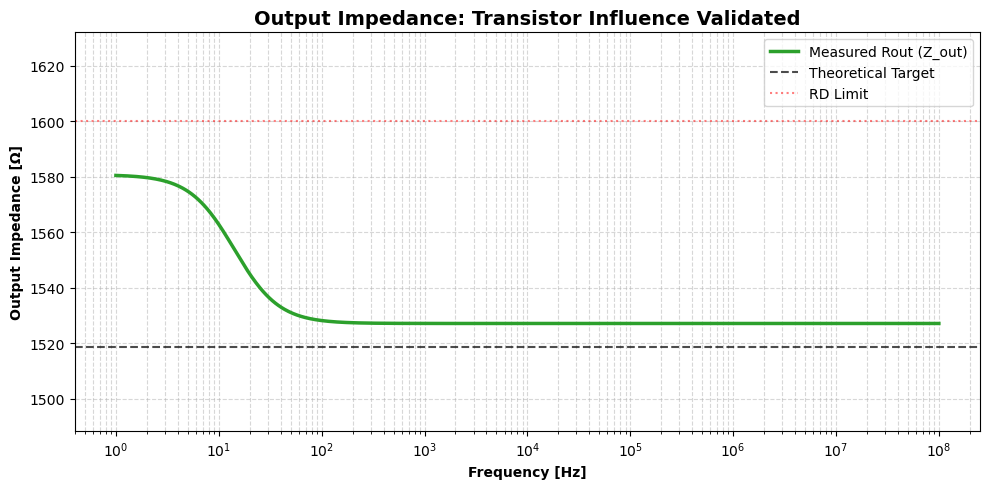

In [177]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("🛡️ [Phase 4] Correcting Rout Extraction (Robust Axis Method)...")

# ===================================================================
# 0. DIRECTORY MANAGEMENT
# ===================================================================
asset_dir = "./sim_assets/baseline"
result_dir = "./sim_results/baseline/termin4"
export_dir = "./export_data/baseline"

os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

target_netlist = f"{asset_dir}/CS_Amp_Baseline_Termin4_copy.net"

# ===================================================================
# 1. SETUP ENGINE & RUN
# ===================================================================
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"
runner = SimRunner(output_folder=result_dir, simulator=mac_path)

editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 2. ROBUST DATA EXTRACTION 
    # ===================================================================
    ac_file = f"{result_dir}/CS_Amp_Baseline_Termin4_copy_1.raw"
    
    # Cek apakah filenya beneran ada
    if not os.path.exists(ac_file):
        raise FileNotFoundError(f"File {ac_file} tidak ditemukan. Cek folder sim_results!")

    ac_raw = RawRead(ac_file)
    
    # --- HACK ANTI-ERROR AXIS ---
    try:
        freq = ac_raw.get_axis()
        if freq is None:
            freq = ac_raw.get_trace("frequency").get_wave()
    except:
        # Paksa ambil trace bernama 'frequency'
        freq = ac_raw.get_trace("frequency").get_wave()
        
    freq = np.real(freq) # Frekuensi harus bilangan real
    
    # Ekstraksi V(drain). Karena Itest = 1A AC, maka V(drain) = Impedansi (Ohm)
    try:
        v_drain_ac = ac_raw.get_trace("v(drain)").get_wave()
        rout_magnitude = np.abs(v_drain_ac)
    except Exception as e:
        print("⚠️ Node v(drain) tidak ditemukan! Pastikan node output di netlist lu namanya 'Drain'.")
        raise e
    
    # ===================================================================
    # 3. ANALYSIS & COMPARISON
    # ===================================================================
    idx_1k = np.argmin(np.abs(freq - 1000))
    measured_rout = rout_magnitude[idx_1k]
    
    # Ambil gm, ro, RD, RS1 dari memori Phase 1
    r_looking_down = ro + RS1_e24 + (gm * ro * RS1_e24)
    theoretical_rout = (RD_e24 * r_looking_down) / (RD_e24 + r_looking_down)
    
    error_percent = abs(measured_rout - theoretical_rout) / theoretical_rout * 100

    print("\n✅ === FINAL OUTPUT IMPEDANCE VERIFICATION === ✅")
    res_rout = [
        ["RD Fixed Value", f"{RD_e24:.2f} Ω"],
        ["Theoretical Rout (Exact)", f"{theoretical_rout:.4f} Ω"],
        ["Simulated Rout (Itest Method)", f"{measured_rout:.4f} Ω"],
        ["Difference (Error)", f"{error_percent:.6f} %"]
    ]
    display(HTML(pd.DataFrame(res_rout, columns=['Parameter', 'Value']).to_html(index=False)))

    # ===================================================================
    # 4. PLOTTING (ZOOMED)
    # ===================================================================
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.semilogx(freq, rout_magnitude, color='#2ca02c', linewidth=2.5, label='Measured Rout (Z_out)')
    ax.axhline(theoretical_rout, color='black', linestyle='--', alpha=0.7, label='Theoretical Target')
    ax.axhline(RD_e24, color='red', linestyle=':', alpha=0.5, label='RD Limit')
    
    # Zoom Y biar kelihatan bedanya antara RD (1600) dan Rout (~1517)
    y_min = min(measured_rout, theoretical_rout) * 0.98
    y_max = max(measured_rout, theoretical_rout, RD_e24) * 1.02
    ax.set_ylim(y_min, y_max)
    
    ax.set_xlabel('Frequency [Hz]', fontweight='bold')
    ax.set_ylabel('Output Impedance [Ω]', fontweight='bold')
    ax.set_title('Output Impedance: Transistor Influence Validated', fontsize=14, fontweight='bold')
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f"{export_dir}/Termin4_rout_plot_baseline_FINAL.png", dpi=300)
    plt.show()

except Exception as e:
    print(f"❌ Error during Phase 4 Extraction: {e}")
    print("\n💡 TIPS DEBUGGING:")
    print("1. Cek file .log di sim_results/baseline/termin4/ apakah ada Fatal Error.")
    print("2. Pastikan di netlist lu ada perintah '.ac dec 100 1 100Meg'.")
    print("3. Pastikan sumber arus lu namanya 'Itest' dan node-nya 'Drain'.")

# 🔬 Phase 5: MOSFET DC Characterization
**Objective:** To extract the fundamental DC behavior of the NMOS transistor used in the design. This phase isolates the MOSFET from the amplifier circuit to map its intrinsic IV curves.

**Analysis Components:**
1. **Output Characteristics ($I_D$ vs $V_{DS}$):** Sweeping $V_{DS}$ from 0V to 12V for multiple $V_{GS}$ steps (1.5V to 4.5V). This visualizes the transition from Linear/Triode region to the Saturation region.
2. **Transfer Characteristics ($I_D$ vs $V_{GS}$):** A single sweep of $V_{GS}$ at a fixed $V_{DS}$ to confirm the Threshold Voltage ($V_{TH}$) and the Transconductance Parameter ($K_n$).

**Mathematical Foundation:**
In Saturation:
$$I_D = \frac{1}{2} K_n (V_{GS} - V_{TH})^2 (1 + \lambda V_{DS})$$

🔬 [Phase 5] Executing MOSFET DC Characterization (.dc) - Multi-Step...


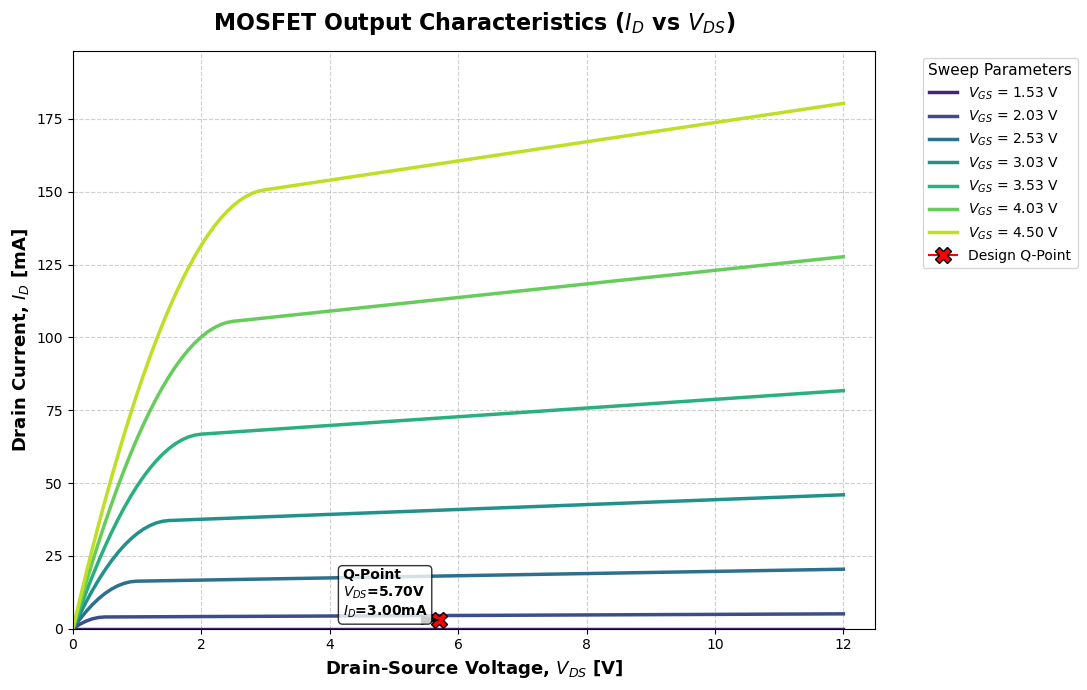


✅ === MOSFET CHARACTERIZATION SUCCESS === ✅
📁 FILES EXPORTED:
- IV Curve Plot : ./export_data/baseline/Termin5_iv_curve_baseline.png
- Datapoints    : ./export_data/baseline/Termin5_mosfet_iv_data_baseline.csv



In [178]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead
from IPython.display import display, HTML

print("🔬 [Phase 5] Executing MOSFET DC Characterization (.dc) - Multi-Step...")

# ===================================================================
# 0. DIRECTORY MANAGEMENT
# ===================================================================
asset_dir = "./sim_assets/baseline"
result_dir = "./sim_results/baseline/termin5"
export_dir = "./export_data/baseline"

os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

# Pastikan netlist testbench lu di-save dengan nama ini ya!
target_netlist = f"{asset_dir}/CS_Amp_Baseline_Termin5_copy.net"

# ===================================================================
# 1. SETUP ENGINE & RUN
# ===================================================================
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"
runner = SimRunner(output_folder=result_dir, simulator=mac_path)

editor = SpiceEditor(target_netlist)
# Injeksi parameter M1 dari blok memori lu (VTO, KP, LAMBDA)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 2. ROBUST MULTI-STEP DATA EXTRACTION (PATCHED)
    # ===================================================================
    dc_file = f"{result_dir}/CS_Amp_Baseline_Termin5_copy_1.raw"
    if not os.path.exists(dc_file):
        raise FileNotFoundError(f"File {dc_file} tidak ditemukan. Cek folder sim_results!")

    dc_raw = RawRead(dc_file)
    steps = dc_raw.get_steps() # Menarik semua langkah Vgs (Outer Sweep)

    fig, ax = plt.subplots(figsize=(11, 7))
    all_data = []

    # Bikin gradasi warna otomatis sesuai jumlah kurva
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(steps)))

    for i, step in enumerate(steps):
        # --- HACK ANTI-ERROR AXIS ---
        # Kita paksa cari sumbu X (Vds) secara manual tanpa peduli get_axis()
        try:
            # Skenario 1: Coba ambil dari fungsi bawaan (tapi di-mute kalau error)
            vds = dc_raw.get_axis(step)
        except:
            vds = None

        if vds is None:
            # Skenario 2: Ambil langsung dari tegangan Node Drain
            try:
                vds = dc_raw.get_trace("v(drain)").get_wave(step)
            except:
                # Skenario 3: LTspice kadang namain sweep source-nya 'v1' atau 'v-sweep'
                try:
                    vds = dc_raw.get_trace("v-sweep").get_wave(step)
                except:
                    vds = dc_raw.get_trace("v1").get_wave(step)
        
        vds = np.real(vds)

        # --- EKSTRAK ARUS DRAIN ---
        # Karena Vds adalah source, arus yang keluar bernilai negatif, makanya -I(Vds)
        try:
            id_trace = dc_raw.get_trace("Id(m1)").get_wave(step)
        except:
            try:
                id_trace = -dc_raw.get_trace("I(Vds)").get_wave(step)
            except:
                id_trace = dc_raw.get_trace("Ix(m1:d)").get_wave(step)

        id_m1 = np.real(id_trace) * 1000  # Konversi ke miliAmpere (mA)

        # Coba ekstrak nilai Vgs saat ini, kalau gagal, dihitung manual dari netlist lu
        try:
            vgs_val = np.real(dc_raw.get_trace("v(gate)").get_wave(step)[0])
        except:
            vgs_val = 1.529 + (i * 0.5) # Fallback sesuai netlist (Vgs 1.529 to 4.5 step 0.5)

        # Plot Kurva Karakteristik per Vgs
        ax.plot(vds, id_m1, label=f'$V_{{GS}}$ = {vgs_val:.2f} V', color=colors[i], linewidth=2.5)

        # Simpan data ke DataFrame List
        for v, i_d in zip(vds, id_m1):
            all_data.append([vgs_val, v, i_d])
    # ===================================================================
    # 3. OVERLAY Q-POINT & PLOT FORMATTING
    # ===================================================================
    # Tarik data dari Block 3 (Perhitungan Eksak) buat nempelin Q-Point!
    try:
        vds_q = VD_ex - VS_ex  # VDS aktual dari desain
        id_q = ID_ex * 1000    # ID aktual (dalam mA)
        
        ax.plot(vds_q, id_q, marker='X', markersize=12, color='red', markeredgecolor='black', label='Design Q-Point')
        ax.annotate(f"Q-Point\n$V_{{DS}}$={vds_q:.2f}V\n$I_D$={id_q:.2f}mA",
                    xy=(vds_q, id_q), xytext=(vds_q - 1.5, id_q + 1.5),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
                    fontsize=10, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))
    except NameError:
        print("⚠️ Variabel VD_ex, VS_ex, atau ID_ex tidak ditemukan di memory. Q-Point di-skip.")

    ax.set_title("MOSFET Output Characteristics ($I_D$ vs $V_{DS}$)", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Drain-Source Voltage, $V_{DS}$ [V]", fontsize=13, fontweight='bold')
    ax.set_ylabel("Drain Current, $I_D$ [mA]", fontsize=13, fontweight='bold')
    
    # Batasin X dan Y axis biar rapih
    ax.set_xlim(0, 12.5)
    ax.set_ylim(0, max(all_data)[2] * 1.1)
    
    ax.grid(True, which="both", ls="--", alpha=0.6)
    
    # Pindahin legend ke luar kotak grafik biar gak nutupin kurva
    ax.legend(title="Sweep Parameters", bbox_to_anchor=(1.05, 1), loc='upper left', title_fontsize='11', fontsize='10')
    plt.tight_layout()

    # ===================================================================
    # 4. EXPORT
    # ===================================================================
    img_filename = f"{export_dir}/Termin5_iv_curve_baseline.png"
    plt.savefig(img_filename, dpi=300, bbox_inches='tight')
    plt.show()

    df_dc = pd.DataFrame(all_data, columns=['VGS_V', 'VDS_V', 'ID_mA'])
    csv_filename = f"{export_dir}/Termin5_mosfet_iv_data_baseline.csv"
    
    # Biar file CSV-nya gak kebesaran, kita slice tiap 5 data points
    df_dc.iloc[::5].to_csv(csv_filename, index=False)

    print(f"\n✅ === MOSFET CHARACTERIZATION SUCCESS === ✅")
    print(f"📁 FILES EXPORTED:")
    print(f"- IV Curve Plot : {img_filename}")
    print(f"- Datapoints    : {csv_filename}\n")

except Exception as e:
    print(f"❌ Error during Phase 5 Extraction: {e}")
    print("\n💡 TIPS DEBUGGING:")
    print("1. Pastikan netlist disimpan sebagai 'CS_Amp_Baseline_Termin5_copy.net'.")
    print("2. Cek apakah node 'Drain' atau 'M1' namanya udah sesuai sama di schematic lu.")

🔬 [Phase 5B] Executing Multi-Vds Transfer Characteristics...


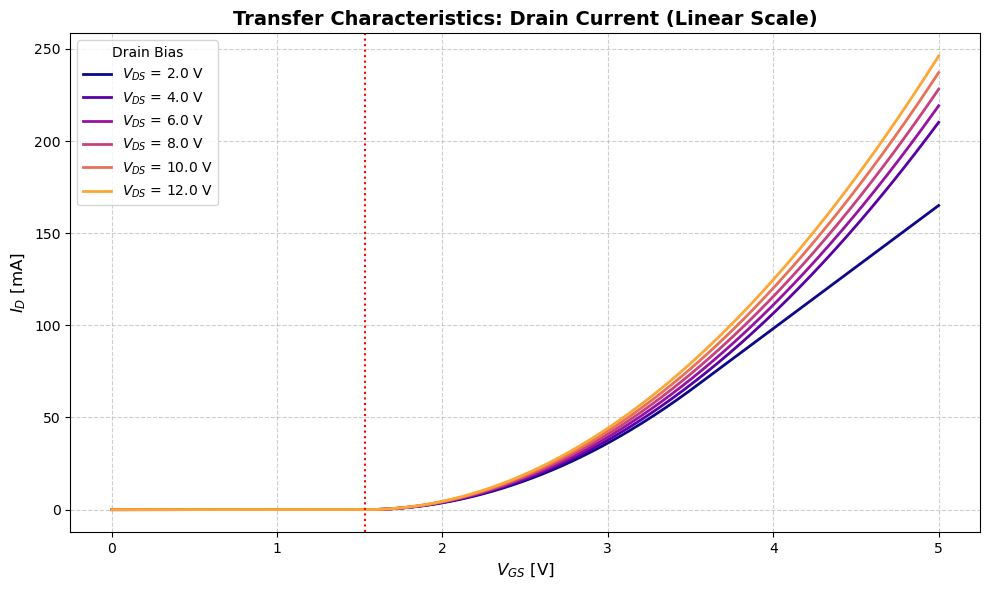

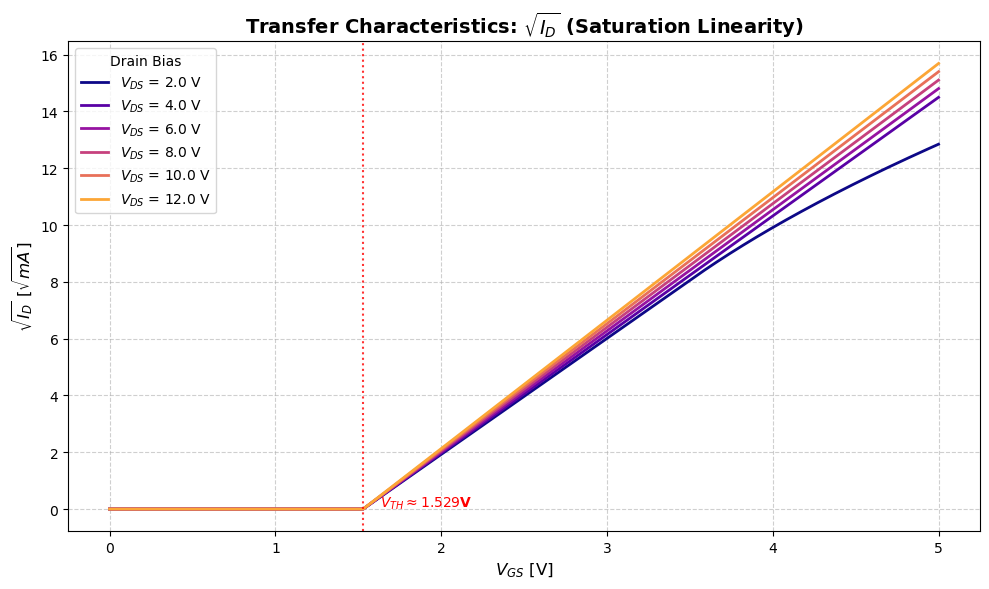

✅ Plot berhasil dipisahkan! Cek folder ./export_data/baseline


In [179]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead

print("🔬 [Phase 5B] Executing Multi-Vds Transfer Characteristics...")

# ===================================================================
# 1. RUN SIMULATION
# ===================================================================
asset_dir = "./sim_assets/baseline"
result_dir = "./sim_results/baseline/termin5"
export_dir = "./export_data/baseline"

target_netlist = f"{asset_dir}/CS_Amp_Baseline_Termin5_Transfer_Sweep.net"
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"

runner = SimRunner(output_folder=result_dir, simulator=mac_path)
editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

try:
    # ===================================================================
    # 2. DATA EXTRACTION
    # ===================================================================
    raw_file = f"{result_dir}/CS_Amp_Baseline_Termin5_Transfer_Sweep_1.raw"
    dc_raw = RawRead(raw_file)
    steps = dc_raw.get_steps()
    
    # Persiapan kontainer plot
    fig1, ax1 = plt.subplots(figsize=(10, 6)) # Plot Linear
    fig2, ax2 = plt.subplots(figsize=(10, 6)) # Plot Sqrt
    
    colors = plt.cm.plasma(np.linspace(0, 0.8, len(steps)))

    for i, step in enumerate(steps):
        # Ekstrak Vgs (Axis)
        try:
            vgs = np.real(dc_raw.get_axis(step))
        except:
            vgs = np.real(dc_raw.get_trace("v(gate)").get_wave(step))
            
        # Ekstrak Id
        try:
            id_m1 = np.real(dc_raw.get_trace("Id(m1)").get_wave(step))
        except:
            id_m1 = np.real(-dc_raw.get_trace("I(Vds)").get_wave(step))
            
        id_mA = id_m1 * 1000
        sqrt_id = np.sqrt(np.maximum(id_mA, 0))
        
        # Ekstrak nilai Vds untuk label
        vds_val = np.real(dc_raw.get_trace("v(drain)").get_wave(step)[0])
        label_str = f'$V_{{DS}}$ = {vds_val:.1f} V'

        # Plot 1: Linear Id vs Vgs
        ax1.plot(vgs, id_mA, label=label_str, color=colors[i], linewidth=2)
        
        # Plot 2: Sqrt(Id) vs Vgs
        ax2.plot(vgs, sqrt_id, label=label_str, color=colors[i], linewidth=2)

    # ===================================================================
    # 3. FORMATTING PLOT 1 (LINEAR)
    # ===================================================================
    ax1.set_title("Transfer Characteristics: Drain Current (Linear Scale)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("$V_{GS}$ [V]", fontsize=12)
    ax1.set_ylabel("$I_D$ [mA]", fontsize=12)
    ax1.grid(True, ls='--', alpha=0.6)
    ax1.legend(title="Drain Bias")
    ax1.axvline(V_TH, color='red', linestyle=':', label='$V_{TH}$ Target')
    
    # ===================================================================
    # 4. FORMATTING PLOT 2 (SQRT)
    # ===================================================================
    ax2.set_title(r"Transfer Characteristics: $\sqrt{I_D}$ (Saturation Linearity)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("$V_{GS}$ [V]", fontsize=12)
    ax2.set_ylabel(r"$\sqrt{I_D}$ [$\sqrt{mA}$]", fontsize=12)
    ax2.grid(True, ls='--', alpha=0.6)
    ax2.legend(title="Drain Bias")
    
    # Identifikasi Vth secara visual di Plot Akar
    ax2.axvline(V_TH, color='red', linestyle=':', alpha=0.8)
    ax2.text(V_TH+0.1, 0.1, f'$V_{{TH}} \\approx {V_TH}$V', color='red', fontweight='bold')

    # Final Touch & Save
    fig1.tight_layout()
    fig2.tight_layout()
    
    fig1.savefig(f"{export_dir}/Termin5_Transfer_Linear_Sweep.png", dpi=300)
    fig2.savefig(f"{export_dir}/Termin5_Transfer_Sqrt_Sweep.png", dpi=300)
    
    plt.show()

    print(f"✅ Plot berhasil dipisahkan! Cek folder {export_dir}")

except Exception as e:
    print(f"❌ Error: {e}")

# 📉 Phase 6: The Load Effect Analysis
**Objective:** Menganalisis seberapa parah degradasi Gain ketika amplifier dihubungkan dengan beban ($R_L$). Karena beban dihubungkan secara AC-coupled (dipisahkan oleh $C_{out}$), titik bias DC tidak akan berubah. Oleh karena itu, kita hanya perlu menumpuk (overlay) hasil Bode Plot (Phase 3) dari Baseline dengan hasil Bode Plot yang sudah diberi beban.

[Phase 6] Executing Load Effect & Input Attenuation Analysis...


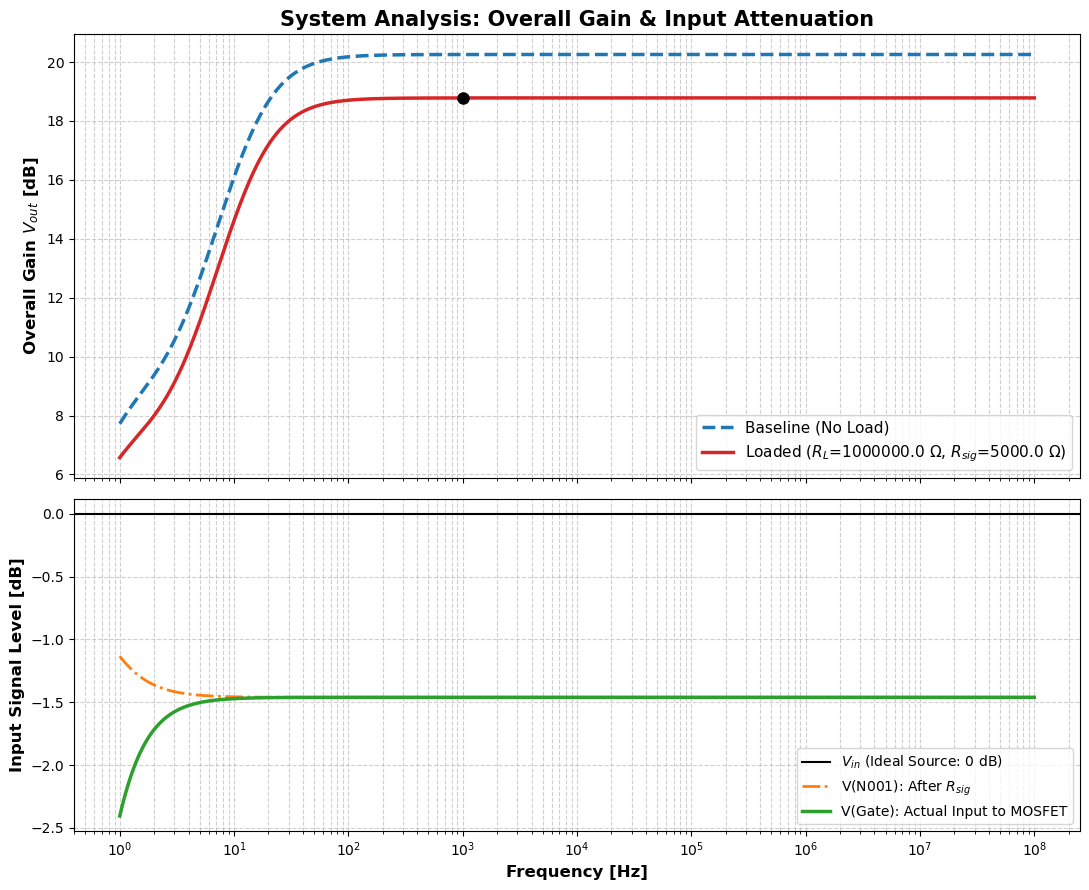


=== PERFORMANCE METRICS @ 1 kHz ===
1. Input Load Effect (Gate Attenuation) : -1.46 dB
2. Output Load Effect (Overall Gain)    : 18.78 dB (Degradation: 1.47 dB)
3. Intrinsic Gain (Gate-to-Drain)       : 20.24 dB
4. Absolute Output Voltage (V_out)      : 8.6914 V


In [180]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PyLTSpice import SimRunner, SpiceEditor, RawRead

%matplotlib inline

print("[Phase 6] Executing Load Effect & Input Attenuation Analysis...")

# ===================================================================
# 1. PARAMETER SETUP
# ===================================================================
my_params['RL_val'] = 1000000.0  # Output load resistance (Ohms)
my_params['Rsig_val'] = 5000.0   # Source internal resistance (Ohms)

# ===================================================================
# 2. SIMULATION EXECUTION
# ===================================================================
asset_dir = "./sim_assets/load_effect" 
result_dir = "./sim_results/load_effect"
export_dir = "./export_data/load_effect"

os.makedirs(result_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

target_netlist = f"{asset_dir}/CS_Amp_Baseline_LoadEffect_copy.net" 
mac_path = "/Applications/LTspice.app/Contents/MacOS/LTspice"

runner = SimRunner(output_folder=result_dir, simulator=mac_path)
editor = SpiceEditor(target_netlist)
editor.set_parameters(**my_params) 
runner.run_now(editor)

# ===================================================================
# 3. DATA EXTRACTION
# ===================================================================
ac_file_load = f"{result_dir}/CS_Amp_Baseline_LoadEffect_copy_1.raw"
ac_raw = RawRead(ac_file_load)
freq_load = np.real(ac_raw.get_trace("frequency").get_wave())

# Pastikan parameter get_trace sesuai dengan nama node di netlist Anda 
# (Ganti "v(out)" jika netlist Anda menggunakan "Out" dan bukan "Vout")
vout_load = ac_raw.get_trace("v(vout)").get_wave() 
mag_db_load = 20 * np.log10(np.abs(vout_load))

# Extract internal nodes
v_n001 = ac_raw.get_trace("v(n001)").get_wave() 
v_gate = ac_raw.get_trace("v(gate)").get_wave() 
v_drain = ac_raw.get_trace("v(drain)").get_wave()

mag_db_n001 = 20 * np.log10(np.abs(v_n001))
mag_db_gate = 20 * np.log10(np.abs(v_gate))
mag_db_drain = 20 * np.log10(np.abs(v_drain))

# ===================================================================
# 4. BASELINE DATA IMPORT
# ===================================================================
baseline_csv = "./export_data/baseline/Termin3_bode_data_baseline.csv"
df_base = pd.read_csv(baseline_csv)
freq_base = df_base['Frequency_Hz']
mag_db_base = df_base['Magnitude_dB']

# ===================================================================
# 5. METRICS CALCULATION (1 kHz)
# ===================================================================
target_freq = 1000.0
idx_1k_load = (np.abs(freq_load - target_freq)).argmin()
idx_1k_base = (np.abs(freq_base - target_freq)).argmin()

gain_1k_load = mag_db_load[idx_1k_load]
gain_1k_base = mag_db_base.iloc[idx_1k_base]
gate_att_1k = mag_db_gate[idx_1k_load] 

# Calculate absolute output voltage magnitude (V/V)
vout_abs_1k = np.abs(vout_load[idx_1k_load])

# Calculate Gate-to-Drain Gain in dB
intrinsic_gain_1k = mag_db_drain[idx_1k_load] - mag_db_gate[idx_1k_load]

# ===================================================================
# 6. PLOTTING
# ===================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1.5]})

# --- PANEL 1: OVERALL GAIN ---
ax1.semilogx(freq_base, mag_db_base, color='#1f77b4', linestyle='--', linewidth=2.5, label='Baseline (No Load)')
ax1.semilogx(freq_load, mag_db_load, color='#d62728', linewidth=2.5, label=rf"Loaded ($R_L$={my_params['RL_val']} $\Omega$, $R_{{sig}}$={my_params['Rsig_val']} $\Omega$)")
ax1.plot(freq_load[idx_1k_load], gain_1k_load, marker='o', markersize=8, color='black')

ax1.set_title("System Analysis: Overall Gain & Input Attenuation", fontsize=15, fontweight='bold')
ax1.set_ylabel('Overall Gain $V_{out}$ [dB]', fontsize=12, fontweight='bold')
ax1.grid(True, which="both", ls="--", alpha=0.6)
ax1.legend(fontsize=11, loc='lower right')

# --- PANEL 2: INPUT ATTENUATION ---
ax2.axhline(0, color='black', linestyle='-', linewidth=1.5, label='$V_{in}$ (Ideal Source: 0 dB)')
ax2.semilogx(freq_load, mag_db_n001, color='#ff7f0e', linestyle='-.', linewidth=2, label=r'V(N001): After $R_{sig}$')
ax2.semilogx(freq_load, mag_db_gate, color='#2ca02c', linewidth=2.5, label='V(Gate): Actual Input to MOSFET')

ax2.set_ylabel('Input Signal Level [dB]', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frequency [Hz]', fontsize=12, fontweight='bold')
ax2.grid(True, which="both", ls="--", alpha=0.6)
ax2.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(f"{export_dir}/DualPanel_Load_Input_Effect.png", dpi=300)
plt.show()

# ===================================================================
# 7. SUMMARY REPORT (@ 1 kHz)
# ===================================================================
print(f"\n=== PERFORMANCE METRICS @ 1 kHz ===")
print(f"1. Input Load Effect (Gate Attenuation) : {gate_att_1k:.2f} dB")
print(f"2. Output Load Effect (Overall Gain)    : {gain_1k_load:.2f} dB (Degradation: {gain_1k_base - gain_1k_load:.2f} dB)")
print(f"3. Intrinsic Gain (Gate-to-Drain)       : {intrinsic_gain_1k:.2f} dB")
print(f"4. Absolute Output Voltage (V_out)      : {vout_abs_1k:.4f} V")
print(f"===================================")